## Analyse regression nPRF results

1. group comparisons of MUs
2. Check distributions of MUs

### next steps cleaner in `regression_encoding_ana_02/3.ipynb`, 
2-for cluster (prep. to .nii), 3-for cloud (trans. to surface)

3. Plot model's R2 on surface (save to .nii and then transform to fsnative and fsaverage5)
4. Compare to normal nPRFs cvr2 (read in  .nii and then transform to fsnative and fsaverage5)

In [1]:
import os
import os.path as op
import numpy as np
import pandas as pd

bids_folder= '/mnt_01/ds-stressrisk' #'/shares/zne.uzh/mrenke/ds-stressrisk'
subject_list = [f[4:] for f in os.listdir(bids_folder) if f[0:3] == 'sub' and len(f) == 6]
all_subjects_set = set(subject_list)
sub_array= np.array([int(i) for i in subject_list]) 

group_mapping = pd.read_csv(op.join(bids_folder,'group_assignmentList.csv'))[['subject','group']].set_index('subject')


In [2]:
from stress_risk.utils.data import Subject
from nilearn.maskers import NiftiMasker
from nilearn import image

def get_vselect_mask(sub, bids_folder):
    roi='NPC_R'
    source_key_vselect = 'encoding_model.cv.denoise.retroicor'
    session1 = 1
    subject = Subject(int(sub), bids_folder=bids_folder)
    ips_mask = subject.get_volume_mask(roi=roi, session=1, epi_space=True) # anat from session1
    ips_masker = NiftiMasker(mask_img=ips_mask)
    im_cvr2_fn = op.join(bids_folder, 'derivatives', source_key_vselect, f'sub-{sub}', f'ses-{session1}','func', f'sub-{sub}_ses-{session1}_desc-cvr2.optim_space-T1w_pars.nii.gz')
    im_cvr2 = image.load_img(im_cvr2_fn)
    cv_r2 = pd.DataFrame(ips_masker.fit_transform(im_cvr2))
    r2_mask = cv_r2 > 0.0
    r2_mask = r2_mask.to_numpy().flatten()
    print(f'Number of voxels: {r2_mask.sum()}')
    return r2_mask
    

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/tqdm-4.64.1-py3.10.egg/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
key = 'encoding_model.model6.retroicor'
param = 'mu'

difs = []
difs_mean = []
difs_sd = []
for sub in subject_list:
    r2_mask = get_vselect_mask(sub, bids_folder)
    fn1 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.1.optim_space-T1w_pars.npy')
    dat_mu1 = np.load(fn1)[r2_mask]
    fn2 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.2.optim_space-T1w_pars.npy')
    dat_mu2 = np.load(fn2)[r2_mask]
    dif = dat_mu2 - dat_mu1
    difs.append(dif)
    difs_mean.append(dif.mean())
    difs_sd.append(dif.std())


In [ ]:
# take log before averaging/or median calculation (less sensitive to outliers)
key = 'encoding_model.model6.retroicor'
param = 'mu'

data = []
for sub in subject_list:
    r2_mask = get_vselect_mask(sub, bids_folder)
    fn1 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.1.optim_space-T1w_pars.npy')
    dat_mu1 = np.load(fn1)[r2_mask]
    fn2 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.2.optim_space-T1w_pars.npy')
    dat_mu2 = np.load(fn2)[r2_mask]
    data.append(pd.DataFrame({'dat_mu1':dat_mu1, 'dat_mu2':dat_mu2, 
                'voxel_n':np.arange(len(dat_mu1)), 'subject':int(sub)}))


In [7]:
df = pd.concat(data, ignore_index=True).set_index(['subject','voxel_n'])
df['log_mu1'] = np.log(df['dat_mu1'])
df['log_mu2'] = np.log(df['dat_mu2'])
df['log_dif'] = df['log_mu2'] - df['log_mu1']
df.head()

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


dat_mu1    dat_mu2   log_mu1   log_mu2   log_dif
subject voxel_n                                                    
12      0         6.047823  28.577398  1.799698  3.352616  1.552918
        1         8.940747  21.733858  2.190619  3.078871  0.888252
        2        19.035944  55.250793  2.946329  4.011883  1.065554
        3        20.793861  18.273127  3.034658  2.905432 -0.129226
        4        18.794910  58.680202  2.933586  4.072103  1.138516

## Plot results 

In [ ]:
df = pd.DataFrame(np.array(difs_mean), index=sub_array,columns=['mean_mu_dif'])
df.index.name = 'subject'
df = df.join(group_mapping).set_index('group',append=True)
y_var = 'mean_mu_dif'
tmp = df.copy()


In [14]:
df = df.join(group_mapping).set_index('group',append=True)
tmp = df.groupby(['subject','group']).mean()
y_var = 'log_dif'

In [15]:
y_var = 'log_dif'
tmp.head()

,,dat_mu1,dat_mu2,log_mu1,log_mu2,log_dif
subject,group,,,,,
1,0,27.519009,26.742676,3.194124,3.139273,-0.044014
2,0,28.155586,24.451939,3.192491,3.038637,-0.153854
3,1,22.082193,24.834711,2.917604,2.974026,0.056423
4,1,13.181956,28.725950,2.695991,3.211855,0.433149
5,0,25.173990,19.309559,3.085638,2.827658,-0.257043


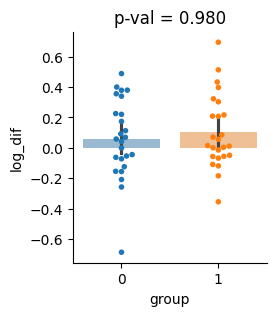

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

_, p_value = ttest_ind(tmp.xs(0,0,'group'),tmp.xs(1,0,'group'), equal_var=False)  # Welch's t-test

fig, ax = plt.subplots(1,1, figsize=(2.5,3)) # , sharex=True, sharey=True
sns.barplot(data=tmp.reset_index(), x ='group', y =y_var ,hue='group', alpha=0.5,legend=False, ax=ax)
sns.swarmplot(data=tmp.reset_index(), y =y_var , x ='group', hue='group',size=4,legend=False, ax=ax)
ax.set(title=f'p-val = {p_value[0]:.3f}')

sns.despine()

(array([ 5.,  1.,  8.,  7., 13.,  2., 15., 20., 15.,  7.]),
 array([-43.337883 , -34.217014 , -25.096148 , -15.975279 ,  -6.854411 ,
          2.2664566,  11.387324 ,  20.508192 ,  29.62906  ,  38.749928 ,
         47.870796 ], dtype=float32),
 <BarContainer object of 10 artists>)

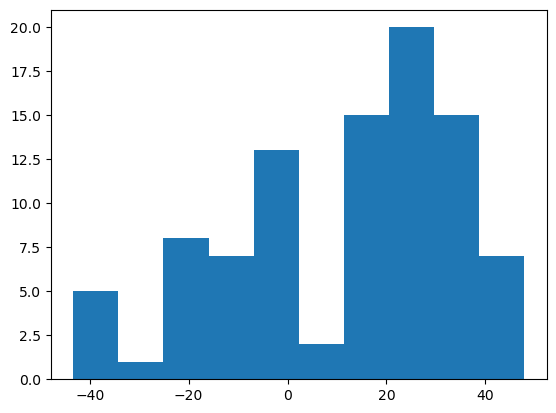

In [6]:
plt.hist(difs[0])

(array([ 1.,  8.,  9., 10., 11., 17.,  9., 10.,  8., 17.]),
 array([-1.887785 ,  3.8364184,  9.560621 , 15.284825 , 21.009027 ,
        26.73323  , 32.457436 , 38.181637 , 43.90584  , 49.630043 ,
        55.354248 ], dtype=float32),
 <BarContainer object of 10 artists>)

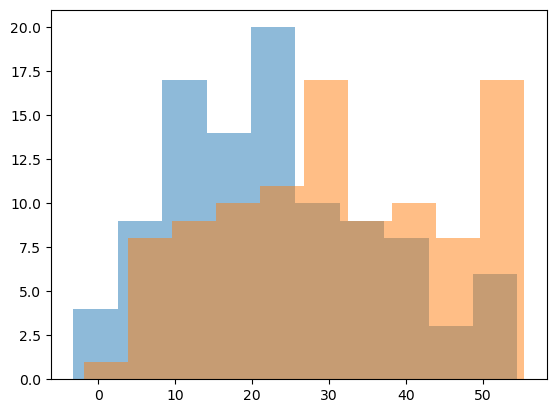

In [7]:
plt.hist(dat_mu1,alpha=0.5)
plt.hist(dat_mu2,alpha=0.5)


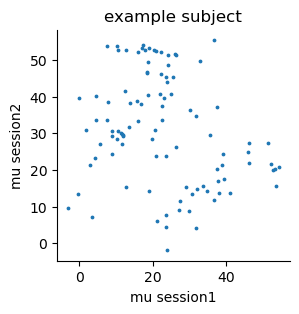

In [20]:
fig, axs = plt.subplots(1,1, figsize=(3,3),sharey=True) # , sharex=True, sharey=True
axs.set(xlabel='mu session1', ylabel='mu session2', title='example subject')
axs.scatter(dat_mu1,dat_mu2, s=3)
sns.despine()

In [ ]:
# only use voxels with mu (from ses 1) >/< 25

thresh = 25

key = 'encoding_model.model6.retroicor'
param = 'mu'

meanDifs_larger25 = []
meanDifs_smaller25 = []
for sub in subject_list:
    r2_mask = get_vselect_mask(sub, bids_folder)
    fn1 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.1.optim_space-T1w_pars.npy')
    dat_mu1 = np.load(fn1)[r2_mask]
    fn2 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.2.optim_space-T1w_pars.npy')
    dat_mu2 = np.load(fn2)[r2_mask]
    dif = dat_mu2 - dat_mu1
    meanDifs_larger25.append(dif[dat_mu1 > thresh].mean())
    meanDifs_smaller25.append(dif[dat_mu1 < thresh].mean())


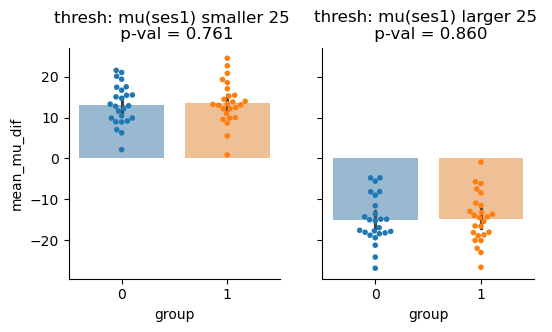

In [ ]:
y_var = 'mean_mu_dif'
fig, axs = plt.subplots(1,2, figsize=(6,3),sharey=True) # , sharex=True, sharey=True

for i, spec in enumerate(['smaller', 'larger']):
    difs = meanDifs_smaller25 if spec ==  'smaller' else meanDifs_larger25
    df = pd.DataFrame(np.array(difs), index=sub_array,columns=['mean_mu_dif'])
    df.index.name = 'subject'
    df = df.join(group_mapping).set_index('group',append=True)
    tmp = df.copy()

    _, p_value = ttest_ind(tmp.xs(0,0,'group'),tmp.xs(1,0,'group'), equal_var=False)  # Welch's t-test
    sns.barplot(data=tmp.reset_index(), x ='group', y =y_var ,hue='group', alpha=0.5,legend=False, ax=axs[i])
    sns.swarmplot(data=tmp.reset_index(), y =y_var , x ='group', hue='group',size=4,legend=False, ax=axs[i])
    axs[i].set(title=f'thresh: mu(ses1) {spec} {thresh} \n p-val = {p_value[0]:.3f}')
    sns.despine()

In [10]:
param = 'mu'
key = 'encoding_model.model6.retroicor'

sub ='02'
r2_mask = get_vselect_mask(sub, bids_folder)
fn1 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.1.optim_space-T1w_pars.npy')
dat_mu1 = np.load(fn1)
fn2 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.2.optim_space-T1w_pars.npy')
dat_mu2 = np.load(fn2)
dif = (dat_mu2 - dat_mu1)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/nilearn/image/resampling.py:684: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


Number of voxels: 54


IndexError: boolean index did not match indexed array along dimension 0; dimension is 1072 but corresponding boolean dimension is 1104

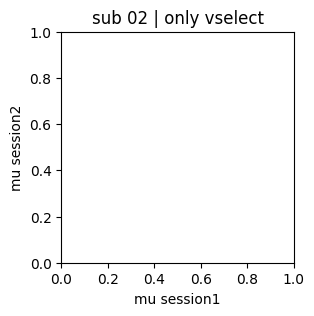

In [ ]:
import matplotlib.pyplot as plt
# r2_mask mismatch on sciencecloud

fig, axs = plt.subplots(1,1, figsize=(3,3),sharey=True) # , sharex=True, sharey=True
axs.set(xlabel='mu session1', ylabel='mu session2', title=f'sub {sub} | only vselect')
axs.scatter(dat_mu1[r2_mask],dat_mu2[r2_mask], s=3)
sns.despine()

fig, axs = plt.subplots(1,1, figsize=(3,3),sharey=True) # , sharex=True, sharey=True
axs.set(xlabel='mu session1', ylabel='mu session2', title=f'sub {sub}| all NPC voxels')
axs.scatter(dat_mu1,dat_mu2, s=3)
sns.despine()

# Visualize R2 on brain surface

bit tricky... saving to .nii file best on sciencecluster (probably due to running fmriprep multiple times...)
transforming to surface space on sciencecloud!

In [ ]:
surf_mask_R = op.join(bids_folder, 'derivatives/surface_masks', 'desc-NPC_R_space-fsaverage5_hemi-rh.label.gii')
surf_mask_R = nb.load(surf_mask_R).agg_data()

from nipype.interfaces.freesurfer import SurfaceTransform

def transform_fsaverage5(in_file, fs_hemi, source_subject, bids_folder):

    subjects_dir = op.join(bids_folder, 'derivatives', 'freesurfer')

    sxfm = SurfaceTransform(subjects_dir=subjects_dir)
    sxfm.inputs.source_file = in_file
    sxfm.inputs.out_file = in_file.replace('fsnative', 'fsaverage5')
    sxfm.inputs.source_subject = source_subject
    sxfm.inputs.target_subject = 'fsaverage5'
    sxfm.inputs.hemi = fs_hemi

    r = sxfm.run()

In [15]:
param = 'r2'
sub ='48'
key = 'encoding_model.model6.retroicor'
target_dir = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func')

fn1 =  op.join(target_dir, f'sub-{sub}_desc-{param}.optim_space-T1w_pars.npy')
r2_im = np.load(fn1)
print(len(r2_im))

807


In [16]:
subject = Subject(int(sub), bids_folder=bids_folder)

ips_mask = subject.get_volume_mask(roi='NPC_R', session=1, epi_space=True) # anat from session1
ips_masker = NiftiMasker(mask_img=ips_mask)
np.sum(ips_masker.mask_img.get_fdata())

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/nilearn/image/resampling.py:684: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


799.0

In [ ]:
# sciencecluster !
ips_masker.fit()
prf_pars_volume = ips_masker.inverse_transform(r2_im)
ips_masker.inverse_transform(r2_im).to_filename(op.join(target_dir, f'sub-{sub}_desc-{param}.optim_space-T1w_pars.nii.gz'))

In [ ]:
# sciencecloud !
from nilearn import surface
import nibabel as nb

surfinfo = subject.get_surf_info_fs()

prf_pars_volume = op.join(target_dir, f'sub-{sub}_desc-{param}.optim_space-T1w_pars.nii.gz')
print(f'Writing to {target_dir}')

for hemi in ['L', 'R']:
    samples = surface.vol_to_surf(prf_pars_volume, surfinfo[hemi]['outer'], inner_mesh=surfinfo[hemi]['inner'])
    fs_hemi = 'lh' if hemi == 'L' else 'rh'

    im = nb.gifti.GiftiImage(darrays=[nb.gifti.GiftiDataArray(samples)])
    target_fn =  op.join(target_dir, f'sub-{sub}_desc-{param}.optim.nilearn_space-fsnative_hemi-{hemi}.func.gii')
    nb.save(im, target_fn)

    transform_fsaverage5(target_fn, fs_hemi, f'sub-{sub}', bids_folder)

Text(0.5, 0.98, 'sub: 48, regression  nPRF r2')

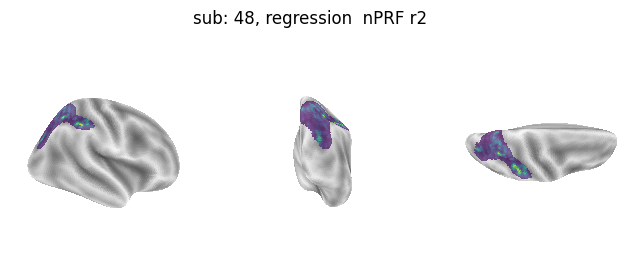

In [46]:
hemi = 'R'
param = 'r2'
target_dir = op.join(bids_folder, 'derivatives','encoding_model.model6.retroicor', f'sub-{sub}', 'func')

fn =  op.join(target_dir, f'sub-{sub}_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
map = nb.load(fn).agg_data()
map[~surf_mask_R.astype(bool)] = np.nan

from  nilearn.datasets import fetch_surf_fsaverage
# for plotting
fsaverage = fetch_surf_fsaverage() # default 5

import nilearn.plotting as nplt
import matplotlib.pyplot as plt

figure, axes = plt.subplots(nrows=1, ncols=3,figsize = (8,3), subplot_kw=dict(projection='3d'))
for i, view in enumerate(['medial','posterior','dorsal']):
    nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= map, # infl_right # pial_right cmap=cmap_two, 
                view=view,colorbar=False, axes=axes[i],
                bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7) #

figure.suptitle(f'sub: {sub}, regression  nPRF {param}')


### compare to cvr2 of normal (non-regression) nPRFs ses1/2

In [47]:
ses = 2
param = 'cvr2'
target_dir = op.join(bids_folder, 'derivatives', 'encoding_model.cv.denoise.retroicor', f'sub-{sub}', f'ses-{ses}','func')

prf_pars_volume = op.join(target_dir,f'sub-{sub}_ses-{ses}_desc-{param}.optim_space-T1w_pars.nii.gz')

for hemi in ['L', 'R']:
    samples = surface.vol_to_surf(prf_pars_volume, surfinfo[hemi]['outer'], inner_mesh=surfinfo[hemi]['inner'])
    fs_hemi = 'lh' if hemi == 'L' else 'rh'

    im = nb.gifti.GiftiImage(darrays=[nb.gifti.GiftiDataArray(samples)])
    target_fn =  op.join(target_dir, f'sub-{sub}_ses-{ses}_desc-{param}.optim.nilearn_space-fsnative_hemi-{hemi}.func.gii')
    nb.save(im, target_fn)

    transform_fsaverage5(target_fn, fs_hemi, f'sub-{sub}', bids_folder)


250313-10:13:56,644 nipype.interface INFO:
	 stderr 2025-03-13T10:13:56.644484:** DA[0] has coordsys with intent NIFTI_INTENT_NONE (should be NIFTI_INTENT_POINTSET)
250313-10:13:57,76 nipype.interface INFO:
	 stdout 2025-03-13T10:13:57.076519:
250313-10:13:57,77 nipype.interface INFO:
	 stdout 2025-03-13T10:13:57.076519:7.3.2
250313-10:13:57,77 nipype.interface INFO:
	 stdout 2025-03-13T10:13:57.076519:
250313-10:13:57,78 nipype.interface INFO:
	 stdout 2025-03-13T10:13:57.076519:setenv SUBJECTS_DIR /mnt_01/ds-stressrisk/derivatives/freesurfer
250313-10:13:57,78 nipype.interface INFO:
	 stdout 2025-03-13T10:13:57.076519:cd /home/ubuntu/git/stress_risk/stress_risk/analyse_results
250313-10:13:57,79 nipype.interface INFO:
	 stdout 2025-03-13T10:13:57.076519:mri_surf2surf --hemi lh --tval /mnt_01/ds-stressrisk/derivatives/encoding_model.cv.denoise.retroicor/sub-48/ses-2/func/sub-48_ses-2_desc-cvr2.optim.nilearn_space-fsaverage5_hemi-L.func.gii --sval /mnt_01/ds-stressrisk/derivatives/enco

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/nilearn/surface/surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


250313-10:13:58,993 nipype.interface INFO:
	 stderr 2025-03-13T10:13:58.993207:** DA[0] has coordsys with intent NIFTI_INTENT_NONE (should be NIFTI_INTENT_POINTSET)
250313-10:13:59,402 nipype.interface INFO:
	 stdout 2025-03-13T10:13:59.402602:
250313-10:13:59,403 nipype.interface INFO:
	 stdout 2025-03-13T10:13:59.402602:7.3.2
250313-10:13:59,404 nipype.interface INFO:
	 stdout 2025-03-13T10:13:59.402602:
250313-10:13:59,404 nipype.interface INFO:
	 stdout 2025-03-13T10:13:59.402602:setenv SUBJECTS_DIR /mnt_01/ds-stressrisk/derivatives/freesurfer
250313-10:13:59,404 nipype.interface INFO:
	 stdout 2025-03-13T10:13:59.402602:cd /home/ubuntu/git/stress_risk/stress_risk/analyse_results
250313-10:13:59,405 nipype.interface INFO:
	 stdout 2025-03-13T10:13:59.402602:mri_surf2surf --hemi rh --tval /mnt_01/ds-stressrisk/derivatives/encoding_model.cv.denoise.retroicor/sub-48/ses-2/func/sub-48_ses-2_desc-cvr2.optim.nilearn_space-fsaverage5_hemi-R.func.gii --sval /mnt_01/ds-stressrisk/derivative

Text(0.5, 0.98, 'sub: 48, ses-1 nPRF cvr2')

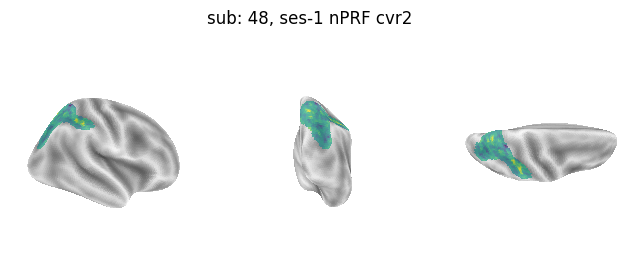

In [52]:
hemi = 'R'
ses = 1
target_dir = op.join(bids_folder, 'derivatives', 'encoding_model.cv.denoise.retroicor', f'sub-{sub}', f'ses-{ses}','func')

fn =  op.join(target_dir, f'sub-{sub}_ses-{ses}_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
map = nb.load(fn).agg_data()
map[~surf_mask_R.astype(bool)] = np.nan

figure, axes = plt.subplots(nrows=1, ncols=3,figsize = (8,3), subplot_kw=dict(projection='3d'))
for i, view in enumerate(['medial','posterior','dorsal']):
    nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= map, # infl_right # pial_right cmap=cmap_two, 
                view=view,colorbar=False, axes=axes[i],
                bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7) #

figure.suptitle(f'sub: {sub}, ses-{ses} nPRF {param}')


In [3]:
sub = '48'
hemi = 'R'
param = 'r2'

fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-1','func', f'sub-{sub}_ses-1_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
npc_ses1 = nb.load(fn).agg_data()

fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-2','func', f'sub-{sub}_ses-2_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
npc_ses2 = nb.load(fn).agg_data()

fn = op.join(bids_folder, 'derivatives', 'encoding_model.model6.retroicor', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
npc_reg = nb.load(fn).agg_data()


NameError: name 'nb' is not defined